# Visual Feature Analysis of Pork Freshness Classes

**Purpose:** Objectively determine whether there are measurable visual differences
between pork freshness classes (*fresh*, *not fresh*, *spoiled*) in the MeatLens
dataset using colour, texture, and statistical analysis.

**Dataset:** 8 physical pork samples (Shoulder, Belly, Ham, Loin) with ROI-extracted,
background-reduced, 224×224 images stored under `processed_hsv_lab_threshold_roi_224/`.

**Statistical design:** Each physical pork sample is photographed many times across
its freshness life-cycle, producing hundreds of ROI images per sample.  Because
images from the same sample are **not independent**, all inferential tests aggregate
to **one observation per sample per freshness class** before testing.  Repeated-
measures ANOVA (or Friedman) is used instead of pooled one-way ANOVA / Kruskal-
Wallis.

> **Note:** This notebook performs statistical analysis only — no machine-learning
> models are trained.

---

## Step 0 — Imports & Configuration

In [1]:
# ==============================================================
# Imports
# ==============================================================
import os
import sys
import warnings
import pathlib
import time as time_module

import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy
from scipy import stats
from scipy.spatial.distance import cdist
from tqdm.notebook import tqdm

# Repeated-measures & mixed-effects
import pingouin as pg
import statsmodels.formula.api as smf

# Dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif, mutual_info_classif
import umap

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Suppress convergence warnings from statsmodels/sklearn
import statsmodels.tools.sm_exceptions as sm_exc
warnings.filterwarnings("ignore", category=sm_exc.ConvergenceWarning)
from sklearn.exceptions import ConvergenceWarning as SKConvergenceWarning
warnings.filterwarnings("ignore", category=SKConvergenceWarning)

# ==============================================================
# Configuration
# ==============================================================
BASE_DIR = pathlib.Path(r"E:\Thesis Code")
ROI_DIR = BASE_DIR / "processed_hsv_lab_threshold_roi_224"
CSV_PATH = ROI_DIR / "processing_summary.csv"
RESULTS_DIR = BASE_DIR / "results" / "visual_analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Significance level
ALPHA = 0.05

# Freshness class ordering (for consistent plots)
CLASS_ORDER = ["fresh", "not fresh", "spoiled"]

# Colour palette for freshness classes
CLASS_PALETTE = {"fresh": "#2ecc71", "not fresh": "#f39c12", "spoiled": "#e74c3c"}

# GLCM parameters
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPERTIES = ["contrast", "dissimilarity", "homogeneity", "ASM", "energy", "correlation"]

# Matplotlib / Seaborn defaults for thesis-quality figures
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.figsize": (10, 6),
    "savefig.bbox": "tight",
})
sns.set_style("whitegrid")

print("All imports successful.")
print(f"  ROI directory : {ROI_DIR}")
print(f"  CSV path      : {CSV_PATH}")
print(f"  Results dir   : {RESULTS_DIR}")

All imports successful.
  ROI directory : E:\Thesis Code\processed_hsv_lab_threshold_roi_224
  CSV path      : E:\Thesis Code\processed_hsv_lab_threshold_roi_224\processing_summary.csv
  Results dir   : E:\Thesis Code\results\visual_analysis


---
## Step 1 — Load Dataset

Load every ROI image referenced in the processing summary CSV.
Auto-discover sample folders, filter out failed segmentations, and
verify that each image exists on disk.

In [2]:
# ==============================================================
# 1.1  Read the master CSV
# ==============================================================
df_master = pd.read_csv(CSV_PATH)

print(f"Total rows in CSV: {len(df_master)}")
print(f"Columns: {list(df_master.columns)}")

# ==============================================================
# 1.2  Filter out failed segmentations
# ==============================================================
if "segmentation_failed" in df_master.columns:
    n_before = len(df_master)
    df_master = df_master[df_master["segmentation_failed"].astype(str).str.lower() != "true"].copy()
    n_after = len(df_master)
    print(f"Excluded {n_before - n_after} failed segmentations -> {n_after} remaining.")

# ==============================================================
# 1.3  Resolve ROI image paths & verify existence
# ==============================================================
# The processed_output_file column contains the full path to each ROI image.
df_master["roi_path"] = df_master["processed_output_file"].apply(lambda p: pathlib.Path(str(p)))

missing = []
existing_mask = []
for idx, row in df_master.iterrows():
    p = row["roi_path"]
    if p.exists():
        existing_mask.append(True)
    else:
        existing_mask.append(False)
        missing.append(str(p))

df_master = df_master[existing_mask].copy()
print(f"Missing images skipped: {len(missing)}")
print(f"Total images loaded: {len(df_master)}")

# ==============================================================
# 1.4  Standardise columns for downstream use
# ==============================================================
df_master["sample_number"] = df_master["sample_number"].astype(int)
df_master["label"] = df_master["label"].str.strip().str.lower()

# Auto-discover unique samples
sample_numbers = sorted(df_master["sample_number"].unique())
print(f"Samples discovered: {sample_numbers}")

Total rows in CSV: 4615
Columns: ['image_file_name', 'sample_number', 'meat_part', 'label', 'time_frame', 'file_destination', 'sample_id', 'pork_cut', 'split_type', 'fold', 'source', 'processed_output_file', 'segmentation_failed', 'mask_area_ratio', 'center_overlap_ratio', 'number_of_components', 'touches_border']
Excluded 3 failed segmentations -> 4612 remaining.
Missing images skipped: 0
Total images loaded: 4612
Samples discovered: [1, 2, 3, 4, 5, 6, 7, 8]


In [3]:
# ==============================================================
# 1.5  Display dataset summaries
# ==============================================================

print("=" * 60)
print(f"TOTAL IMAGES: {len(df_master)}")
print("=" * 60)

print("\n-- Images per Sample --")
sample_counts = df_master.groupby("sample_number").size().reset_index(name="count")
display(sample_counts)

print("\n-- Images per Freshness Class --")
class_counts = df_master.groupby("label").size().reindex(CLASS_ORDER).reset_index(name="count")
display(class_counts)

print("\n-- Images per Meat Part --")
part_counts = df_master.groupby("meat_part").size().reset_index(name="count")
display(part_counts)

print("\n-- Images per Sample x Class --")
cross = df_master.groupby(["sample_number", "label"]).size().unstack(fill_value=0)
cross = cross.reindex(columns=CLASS_ORDER)
display(cross)

TOTAL IMAGES: 4612

-- Images per Sample --


,sample_number,count
0,1,600
1,2,598
2,3,518
3,4,549
4,5,600
5,6,600
6,7,547
7,8,600



-- Images per Freshness Class --


,label,count
0,fresh,1413
1,not fresh,1600
2,spoiled,1599



-- Images per Meat Part --


,meat_part,count
0,Pork Belly,1067
1,Pork Ham,1200
2,Pork Loin,1147
3,Pork Shoulder,1198



-- Images per Sample x Class --


label,fresh,not fresh,spoiled
sample_number,,,
1,200,200,200
2,198,200,200
3,118,200,200
4,150,200,199
5,200,200,200
6,200,200,200
7,147,200,200
8,200,200,200


---
## Step 2 — Extract Visual Features

For every ROI image, extract colour (LAB, RGB, HSV), texture (GLCM),
entropy, and variance features.

In [4]:
# ==============================================================
# 2.1  Feature extraction function
# ==============================================================

def extract_features(image_path):
    """
    Extract colour, texture, and statistical features from a single
    ROI image.

    Parameters
    ----------
    image_path : pathlib.Path
        Absolute path to the ROI image (224x224 pixels).

    Returns
    -------
    dict
        Dictionary mapping feature name to its computed value.
    """
    # Read image (OpenCV loads as BGR)
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return None

    # -- Colour spaces --
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    features = {}

    # -- LAB colour features --
    L = img_lab[:, :, 0].astype(np.float64)
    A = img_lab[:, :, 1].astype(np.float64)
    B = img_lab[:, :, 2].astype(np.float64)
    features["mean_L"] = np.mean(L)
    features["mean_a"] = np.mean(A)
    features["mean_b"] = np.mean(B)
    features["std_L"]  = np.std(L)
    features["std_a"]  = np.std(A)
    features["std_b"]  = np.std(B)

    # -- RGB colour features --
    R  = img_rgb[:, :, 0].astype(np.float64)
    G  = img_rgb[:, :, 1].astype(np.float64)
    Bc = img_rgb[:, :, 2].astype(np.float64)
    features["mean_R"] = np.mean(R)
    features["mean_G"] = np.mean(G)
    features["mean_B"] = np.mean(Bc)

    # -- HSV colour features --
    H = img_hsv[:, :, 0].astype(np.float64)
    S = img_hsv[:, :, 1].astype(np.float64)
    V = img_hsv[:, :, 2].astype(np.float64)
    features["mean_H"] = np.mean(H)
    features["mean_S"] = np.mean(S)
    features["mean_V"] = np.mean(V)

    # -- GLCM texture features --
    # scikit-image expects uint8 grayscale
    glcm = graycomatrix(
        img_gray,
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=256,
        symmetric=True,
        normed=True,
    )
    for prop in GLCM_PROPERTIES:
        # Average across all angles for a single scalar per property
        values = graycoprops(glcm, prop)  # shape (n_distances, n_angles)
        features[f"glcm_{prop}"] = values.mean()

    # -- Entropy (Shannon) --
    features["entropy"] = shannon_entropy(img_gray)

    # -- Variance (grayscale intensity) --
    features["variance"] = np.var(img_gray.astype(np.float64))

    return features

In [5]:
# ==============================================================
# 2.2  Run extraction over all images
# ==============================================================

# Check for cached results
features_cache_path = BASE_DIR / "visual_features.csv"

if features_cache_path.exists():
    print(f"Loading cached features from {features_cache_path} ...")
    df_features = pd.read_csv(features_cache_path)
    print(f"  Loaded {len(df_features)} rows with {len(df_features.columns)} columns.")
else:
    print(f"Extracting features from {len(df_master)} images (this may take 15-30 min) ...")
    records = []
    failed = 0
    start_time = time_module.time()

    for idx, row in tqdm(df_master.iterrows(), total=len(df_master), desc="Extracting features"):
        feats = extract_features(row["roi_path"])
        if feats is None:
            failed += 1
            continue

        # Attach metadata
        feats["image_file_name"] = row["image_file_name"]
        feats["sample_number"] = row["sample_number"]
        feats["label"] = row["label"]
        feats["time_frame"] = row["time_frame"]
        feats["meat_part"] = row["meat_part"]
        feats["processed_output_file"] = str(row["processed_output_file"])

        records.append(feats)

    elapsed = time_module.time() - start_time
    print(f"\nExtraction complete in {elapsed / 60:.1f} min.")
    print(f"  Successful: {len(records)}  |  Failed: {failed}")

    df_features = pd.DataFrame(records)

    # Save immediately so subsequent runs are instant
    df_features.to_csv(features_cache_path, index=False)
    print(f"  Saved to {features_cache_path}")

# Ensure correct types
df_features["sample_number"] = df_features["sample_number"].astype(int)
df_features["label"] = df_features["label"].str.strip().str.lower()

# Define the list of numeric feature columns for reuse
FEATURE_COLS = [
    "mean_L", "mean_a", "mean_b", "std_L", "std_a", "std_b",
    "mean_R", "mean_G", "mean_B",
    "mean_H", "mean_S", "mean_V",
    "glcm_contrast", "glcm_dissimilarity", "glcm_homogeneity",
    "glcm_ASM", "glcm_energy", "glcm_correlation",
    "entropy", "variance",
]

print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
display(df_features.head())

Loading cached features from E:\Thesis Code\visual_features.csv ...
  Loaded 4612 rows with 26 columns.

Feature columns (20): ['mean_L', 'mean_a', 'mean_b', 'std_L', 'std_a', 'std_b', 'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_ASM', 'glcm_energy', 'glcm_correlation', 'entropy', 'variance']


,mean_L,mean_a,mean_b,std_L,std_a,std_b,mean_R,mean_G,mean_B,mean_H,...,glcm_energy,glcm_correlation,entropy,variance,image_file_name,sample_number,label,time_frame,meat_part,processed_output_file
0,122.790637,143.299645,137.492905,37.597705,12.532480,7.349477,142.536990,104.450096,100.312002,16.445930,...,0.286722,0.974917,6.006034,1400.570463,20260424_055602.jpg,1,fresh,00:00:00,Pork Shoulder,E:\Thesis Code\processed_hsv_lab_threshold_roi...
1,124.598653,131.338787,131.452547,21.862909,4.999737,5.062321,123.369460,114.103456,110.738620,9.288963,...,0.616168,0.922288,3.315347,418.940963,IMG20260423061521.jpg,2,fresh,00:00:00,Pork Shoulder,E:\Thesis Code\processed_hsv_lab_threshold_roi...
2,127.164421,139.764768,133.090462,28.520677,10.574013,4.304466,140.149195,111.245376,110.989836,48.532147,...,0.352362,0.978857,5.351543,780.369581,20260429_042402.jpg,3,fresh,00:00:00,Pork Belly,E:\Thesis Code\processed_hsv_lab_threshold_roi...
3,123.527364,134.493662,133.128986,18.200105,5.468508,4.168910,128.858976,111.034220,106.791673,11.941944,...,0.326417,0.975228,4.913383,294.533017,20260429_065044.jpg,4,fresh,00:00:00,Pork Belly,E:\Thesis Code\processed_hsv_lab_threshold_roi...
4,125.707789,151.871532,136.105190,21.155871,10.503966,4.442498,158.471720,100.944675,104.780812,123.782246,...,0.095041,0.924861,6.064852,465.571847,IMG_20260508_041534.jpg,5,fresh,00:00:00,Pork Ham,E:\Thesis Code\processed_hsv_lab_threshold_roi...


---
## Step 3 — Descriptive Statistics

Compute mean, median, standard deviation, minimum, and maximum for every
feature, grouped by freshness label and by sample number.

In [6]:
# ==============================================================
# 3.1  Descriptive statistics grouped by freshness label
# ==============================================================

desc_by_label = (
    df_features
    .groupby("label")[FEATURE_COLS]
    .agg(["mean", "median", "std", "min", "max"])
)
# Reorder rows
desc_by_label = desc_by_label.reindex(CLASS_ORDER)

print("-- Descriptive Statistics by Freshness Label --")
display(desc_by_label)

-- Descriptive Statistics by Freshness Label --


mean_L                                                \
                 mean      median        std        min         max   
label                                                                 
fresh      118.386588  118.884726  15.967167  80.733119  150.232143   
not fresh  109.477608  108.724749  15.124197  65.863122  152.785176   
spoiled    105.451998  108.846162  11.477475  77.237803  141.444176   

               mean_a                                                ...  \
                 mean      median       std         min         max  ...   
label                                                                ...   
fresh      142.707705  140.205218  8.220383  130.169623  161.306063  ...   
not fresh  142.521554  141.026696  7.092820  131.154815  161.125837  ...   
spoiled    139.216373  139.627850  4.527978  130.912030  149.788883  ...   

            entropy                                             variance  \
               mean    median       std       min       max         mean   
label                                                                      
fresh      5.472438  5.598140  0.851265  2.502182  7.367226   630.547438   
not fresh  5.408776  5.495372  0.658279  2.870127  7.034579   789.311909   
spoiled    5.001913  5.121084  0.722104  3.101764  6.509056  1017.794628   

                                                             
                median         std         min          max  
label                                                        
fresh       522.304427  410.280495  212.994128  2295.596688  
not fresh   666.241604  553.261761  209.986195  3055.040964  
spoiled    1017.668928  487.275569  156.151423  2370.065829  

[3 rows x 100 columns]

In [7]:
# ==============================================================
# 3.2  Descriptive statistics grouped by sample number
# ==============================================================

desc_by_sample = (
    df_features
    .groupby("sample_number")[FEATURE_COLS]
    .agg(["mean", "median", "std", "min", "max"])
)

print("-- Descriptive Statistics by Sample Number --")
display(desc_by_sample)

-- Descriptive Statistics by Sample Number --


mean_L                                                 \
                     mean      median        std         min         max   
sample_number                                                              
1              113.220258  112.266811   5.920120   94.811145  152.785176   
2              115.447653  117.002910   8.435902   93.490135  128.717873   
3              123.776315  125.086765   6.306780  108.217634  137.768893   
4              115.318895  120.414800  10.589924   96.784718  129.211256   
5               98.961372   97.797024  11.951447   65.863122  132.785595   
6               92.036596   93.298928   2.792281   84.876574  100.198083   
7              103.556086  102.858757  10.272831   77.237803  126.894611   
8              125.703582  116.553920  18.299808  101.498924  150.232143   

                   mean_a                                                ...  \
                     mean      median       std         min         max  ...   
sample_number                                                            ...   
1              145.644538  146.649294  4.331071  135.073083  154.588887  ...   
2              133.540799  133.897082  1.060419  130.169623  134.792351  ...   
3              142.447550  142.464007  3.450084  135.125558  152.536591  ...   
4              134.003442  134.623386  1.475993  130.912030  135.933454  ...   
5              151.068968  151.824587  6.861676  137.974251  161.306063  ...   
6              139.753572  140.255800  2.144837  135.266901  145.462552  ...   
7              147.052380  147.559431  3.655125  136.871253  156.082131  ...   
8              137.927394  137.772431  1.995503  135.355050  141.408263  ...   

                entropy                                             variance  \
                   mean    median       std       min       max         mean   
sample_number                                                                  
1              6.100750  6.063922  0.379370  4.808533  7.367226  1837.878650   
2              4.207370  4.324635  0.454002  2.502182  4.667778   622.235987   
3              5.207290  5.046028  0.448177  4.327625  6.437262   935.258875   
4              4.621854  4.951520  0.683271  3.101764  5.517573   498.485719   
5              5.965451  6.017734  0.278809  5.249979  6.509056   764.322189   
6              4.754528  4.835205  0.220480  4.209483  5.678860   705.756424   
7              5.871897  5.964820  0.334725  4.721165  6.406022   870.354445   
8              5.549182  5.597719  0.226173  4.792861  6.047817   317.046792   

                                                                 
                    median         std         min          max  
sample_number                                                    
1              1816.137700  312.969357  879.257877  3055.040964  
2               502.989469  342.726844  260.425624  1595.277491  
3               970.028192  174.395997  626.079334  1523.204241  
4               381.350483  256.982077  212.994128  1151.812776  
5               706.414108  232.050158  442.429799  1619.223224  
6               555.597389  358.962433  393.523789  1521.793163  
7               740.742025  325.264521  378.116238  1834.180616  
8               318.222648   56.368032  156.151423   473.709628  

[8 rows x 100 columns]

In [8]:
# ==============================================================
# 3.3  Save descriptive statistics
# ==============================================================

# Flatten multi-level column index for CSV
def flatten_desc(df, group_name):
    """Flatten multi-index columns into single-level column names."""
    df_flat = df.copy()
    df_flat.columns = [f"{feat}_{stat}" for feat, stat in df_flat.columns]
    df_flat.index.name = group_name
    return df_flat.reset_index()

desc_label_flat = flatten_desc(desc_by_label, "label")
desc_sample_flat = flatten_desc(desc_by_sample, "sample_number")

# Combine into one CSV with a separator
combined_desc = pd.concat([
    pd.DataFrame({"section": ["=== By Label ==="]}),
    desc_label_flat,
    pd.DataFrame({"section": [""]}),
    pd.DataFrame({"section": ["=== By Sample ==="]}),
    desc_sample_flat,
], ignore_index=True)

stats_path = BASE_DIR / "feature_statistics.csv"
combined_desc.to_csv(stats_path, index=False)
print(f"Saved descriptive statistics -> {stats_path}")

Saved descriptive statistics -> E:\Thesis Code\feature_statistics.csv


---
## Step 4 — Sample-Level Aggregation

**Why aggregate?**  The dataset contains hundreds of ROI images per sample,
but those images are *not* independent — they come from the same physical
piece of pork.  Treating each image as an independent observation inflates
sample size and produces misleadingly small p-values.

**Method:**  For every `(sample_number, label)` pair, compute the **mean**
of every extracted feature.  This yields one observation per sample per
freshness class — at most 8 × 3 = 24 rows.

This aggregated dataset is the basis for all inferential statistics from
here on.

In [9]:
# ==============================================================
# 4.1  Aggregate to sample-level means
# ==============================================================

df_agg = (
    df_features
    .groupby(["sample_number", "label"])[FEATURE_COLS]
    .mean()
    .reset_index()
)

print(f"Aggregated dataset shape: {df_agg.shape}")
print(f"  (Expected: up to {len(sample_numbers)} samples x {len(CLASS_ORDER)} classes "
      f"= {len(sample_numbers) * len(CLASS_ORDER)} rows)\n")

# Verify completeness: each sample should appear in all 3 classes
print("-- Sample x Class completeness check --")
completeness = df_agg.groupby("sample_number")["label"].apply(set).reset_index()
completeness.columns = ["sample_number", "classes_present"]
completeness["n_classes"] = completeness["classes_present"].apply(len)
completeness["complete"] = completeness["n_classes"] == len(CLASS_ORDER)
display(completeness)

n_complete = completeness["complete"].sum()
print(f"\n{n_complete}/{len(sample_numbers)} samples have all {len(CLASS_ORDER)} classes.")

if n_complete < len(sample_numbers):
    print("WARNING: Some samples are missing classes. Repeated-measures tests "
          "require balanced data — incomplete samples will be excluded.")
    complete_samples = completeness[completeness["complete"]]["sample_number"].tolist()
    df_agg_rm = df_agg[df_agg["sample_number"].isin(complete_samples)].copy()
else:
    complete_samples = sample_numbers
    df_agg_rm = df_agg.copy()

print(f"\nSamples used for repeated-measures tests: {complete_samples}")
print(f"Aggregated RM dataset shape: {df_agg_rm.shape}")
display(df_agg_rm)

Aggregated dataset shape: (24, 22)
  (Expected: up to 8 samples x 3 classes = 24 rows)

-- Sample x Class completeness check --


,sample_number,classes_present,n_classes,complete
0,1,"{fresh, not fresh, spoiled}",3,True
1,2,"{fresh, not fresh, spoiled}",3,True
2,3,"{fresh, not fresh, spoiled}",3,True
3,4,"{fresh, not fresh, spoiled}",3,True
4,5,"{fresh, not fresh, spoiled}",3,True
5,6,"{fresh, not fresh, spoiled}",3,True
6,7,"{fresh, not fresh, spoiled}",3,True
7,8,"{fresh, not fresh, spoiled}",3,True



8/8 samples have all 3 classes.

Samples used for repeated-measures tests: [1, 2, 3, 4, 5, 6, 7, 8]
Aggregated RM dataset shape: (24, 22)


,sample_number,label,mean_L,mean_a,mean_b,std_L,std_a,std_b,mean_R,mean_G,...,mean_S,mean_V,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_ASM,glcm_energy,glcm_correlation,entropy,variance
0,1,fresh,116.213147,149.250127,142.743768,38.445018,14.288358,9.387723,145.623971,92.798029,...,108.653564,145.731832,72.076409,4.527167,0.378716,0.040086,0.199442,0.976544,6.442485,1539.291381
1,1,not fresh,111.781941,146.889919,137.732327,46.363317,14.392276,7.442359,135.882373,90.897383,...,98.783163,135.979041,77.529189,4.209290,0.432620,0.067652,0.256698,0.981837,6.189117,2130.484784
2,1,spoiled,111.665686,140.793567,133.552400,44.722413,12.070222,6.226606,126.070607,96.156126,...,72.044954,126.158693,105.736126,4.885586,0.460100,0.115974,0.338942,0.970543,5.670647,1843.859786
3,2,fresh,118.696584,132.656136,133.469853,23.659480,5.244135,6.008118,120.730870,107.593667,...,43.804563,120.831039,42.086246,2.961468,0.600134,0.263218,0.502355,0.957051,3.990443,496.483858
4,2,not fresh,121.456951,133.884626,131.248117,21.031961,5.996697,3.267809,124.457754,109.555446,...,35.727552,124.549629,17.943212,1.823893,0.626131,0.189939,0.434283,0.977225,4.362445,393.527406
5,2,spoiled,106.221914,134.072789,131.764878,33.163276,6.356126,4.121661,109.977583,95.480170,...,47.926763,110.044470,25.115876,1.982378,0.632817,0.205484,0.452861,0.987524,4.267054,975.439177
6,3,fresh,130.120897,145.258553,136.261265,28.154558,13.248219,6.091370,152.511175,109.576212,...,74.722242,152.576812,35.169184,2.989742,0.474011,0.084640,0.272443,0.978722,5.748915,837.589242
7,3,not fresh,126.281990,142.950918,136.111685,28.506972,14.845310,7.862502,144.187325,107.097739,...,68.804867,144.281511,39.995340,2.778942,0.557174,0.160665,0.399793,0.975941,5.021881,840.707621
8,3,spoiled,117.527336,140.285691,135.302731,34.227037,11.946937,7.036542,131.411140,101.300624,...,68.383635,131.491741,42.144742,3.003143,0.543981,0.161231,0.400302,0.980623,5.073141,1087.435214
9,4,fresh,126.180963,135.138173,133.604471,16.685496,5.682880,4.261125,132.821781,113.175265,...,46.263268,132.886211,13.263246,1.745762,0.578999,0.087508,0.294151,0.973562,5.038366,251.092859


---
## Step 5 — Repeated-Measures Significance Testing

For each feature, test whether the three freshness classes differ significantly
using the sample-level aggregated data.

Because each physical sample appears in **all three** freshness conditions,
we use **within-subjects** tests:

1. **Check normality** of residuals (Shapiro-Wilk) and **sphericity** (Mauchly).
2. If assumptions hold → **Repeated Measures ANOVA** (`pingouin.rm_anova`).
3. If normality is violated → **Friedman Test** (`pingouin.friedman`).

Significance threshold: α = 0.05.

In [11]:
# ==============================================================
# 5.1  Repeated-Measures testing for each feature
# ==============================================================

rm_results = []

for feat in FEATURE_COLS:
    # Pivot to wide format for normality checks
    wide = df_agg_rm.pivot(index="sample_number", columns="label", values=feat)
    wide = wide[CLASS_ORDER]  # ensure column order

    # Check normality of each group (Shapiro-Wilk)
    all_normal = True
    for cls in CLASS_ORDER:
        vals = wide[cls].dropna().values
        if len(vals) < 3:
            all_normal = False
            break
        _, sw_p = stats.shapiro(vals)
        if sw_p < ALPHA:
            all_normal = False
            break

    if all_normal:
        # Repeated Measures ANOVA via pingouin
        aov = pg.rm_anova(
            data=df_agg_rm, dv=feat, within="label",
            subject="sample_number", detailed=True, correction=True
        )
        test_name = "RM-ANOVA"
        stat_val = aov["F"].values[0]
        p_val = aov["p_unc"].values[0]
        # Effect size: generalised eta-squared
        eta_sq = aov["ng2"].values[0] if "ng2" in aov.columns else np.nan

        # Sphericity info (embedded in output when correction=True)
        spher_p = aov["p_spher"].values[0] if "p_spher" in aov.columns else np.nan
        sphericity_met = aov["sphericity"].values[0] if "sphericity" in aov.columns else True

        # If sphericity violated, use GG-corrected p-value
        if not sphericity_met and "p_GG_corr" in aov.columns:
            p_val = aov["p_GG_corr"].values[0]
            test_name = "RM-ANOVA (GG-corrected)"

        rm_results.append({
            "feature": feat,
            "test_used": test_name,
            "statistic": round(stat_val, 4),
            "p_value": p_val,
            "effect_size_metric": "partial_eta_sq",
            "effect_size": round(eta_sq, 4) if not np.isnan(eta_sq) else np.nan,
            "sphericity_p": round(spher_p, 4) if not (isinstance(spher_p, float) and np.isnan(spher_p)) else np.nan,
            "significant": "Yes" if p_val < ALPHA else "No",
        })
    else:
        # Friedman test (non-parametric repeated measures)
        friedman = pg.friedman(
            data=df_agg_rm, dv=feat, within="label",
            subject="sample_number"
        )
        stat_val = friedman["Q"].values[0]
        p_val = friedman["p_unc"].values[0]

        # Kendall's W = Q / (n * (k-1))
        n_subj = len(complete_samples)
        k = len(CLASS_ORDER)
        kendall_w = stat_val / (n_subj * (k - 1)) if (n_subj * (k - 1)) > 0 else 0.0

        rm_results.append({
            "feature": feat,
            "test_used": "Friedman",
            "statistic": round(stat_val, 4),
            "p_value": p_val,
            "effect_size_metric": "Kendall_W",
            "effect_size": round(kendall_w, 4),
            "sphericity_p": np.nan,
            "significant": "Yes" if p_val < ALPHA else "No",
        })

df_rm = pd.DataFrame(rm_results)

print("-- Repeated-Measures Significance Testing Results --")
display(df_rm)

n_sig = (df_rm["significant"] == "Yes").sum()
print(f"\n{n_sig} / {len(FEATURE_COLS)} features show statistically significant "
      f"differences across freshness classes (alpha = {ALPHA}).")


-- Repeated-Measures Significance Testing Results --


,feature,test_used,statistic,p_value,effect_size_metric,effect_size,sphericity_p,significant
0,mean_L,RM-ANOVA,9.4248,0.002554,partial_eta_sq,0.1797,0.7589,Yes
1,mean_a,RM-ANOVA (GG-corrected),3.6634,0.087615,partial_eta_sq,0.0619,0.0241,No
2,mean_b,RM-ANOVA,4.3406,0.034137,partial_eta_sq,0.1463,0.0712,Yes
3,std_L,Friedman,12.2500,0.002187,Kendall_W,0.7656,NaN,Yes
4,std_a,RM-ANOVA (GG-corrected),0.2262,0.693300,partial_eta_sq,0.0021,0.0462,No
5,std_b,RM-ANOVA,0.0838,0.920041,partial_eta_sq,0.0031,0.1376,No
6,mean_R,RM-ANOVA,19.2431,0.000096,partial_eta_sq,0.3167,0.5526,Yes
7,mean_G,RM-ANOVA,4.5599,0.029854,partial_eta_sq,0.0908,0.6163,Yes
8,mean_B,RM-ANOVA,2.7658,0.097215,partial_eta_sq,0.0768,0.4785,No
9,mean_H,Friedman,2.2500,0.324652,Kendall_W,0.1406,NaN,No



13 / 20 features show statistically significant differences across freshness classes (alpha = 0.05).


---
## Step 6 — Post-Hoc Pairwise Comparisons

For features that showed a significant omnibus effect, perform pairwise
comparisons between all freshness class pairs:

- Fresh vs Not Fresh
- Fresh vs Spoiled
- Not Fresh vs Spoiled

Tests: Paired t-test (if data are normal) or Wilcoxon signed-rank (otherwise).
p-values are corrected using the **Holm** method.

In [13]:
# ==============================================================
# 6.1  Pairwise post-hoc tests
# ==============================================================

sig_features = df_rm[df_rm["significant"] == "Yes"]["feature"].tolist()
pairs = [("fresh", "not fresh"), ("fresh", "spoiled"), ("not fresh", "spoiled")]

posthoc_records = []

for feat in sig_features:
    wide = df_agg_rm.pivot(index="sample_number", columns="label", values=feat)
    wide = wide[CLASS_ORDER]

    raw_ps = []
    pair_details = []

    for cls_a, cls_b in pairs:
        a = wide[cls_a].dropna().values
        b = wide[cls_b].dropna().values

        # Use only matched pairs
        mask = ~(np.isnan(a) | np.isnan(b))
        a, b = a[mask], b[mask]

        if len(a) < 3:
            pair_details.append({
                "feature": feat, "pair": f"{cls_a} vs {cls_b}",
                "test_used": "SKIPPED", "statistic": np.nan,
                "p_raw": np.nan, "cohens_d": np.nan,
            })
            raw_ps.append(np.nan)
            continue

        # Normality of differences
        diff = a - b
        _, sw_p = stats.shapiro(diff)

        if sw_p > ALPHA:
            stat, p = stats.ttest_rel(a, b)
            test_name = "Paired t-test"
        else:
            result = stats.wilcoxon(a, b)
            stat, p = result.statistic, result.pvalue
            test_name = "Wilcoxon"

        # Cohen's d for paired data
        d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else 0.0

        pair_details.append({
            "feature": feat, "pair": f"{cls_a} vs {cls_b}",
            "test_used": test_name, "statistic": round(stat, 4),
            "p_raw": p, "cohens_d": round(d, 4),
        })
        raw_ps.append(p)

    # Holm correction across the 3 pairs for this feature
    valid_ps = [p for p in raw_ps if not np.isnan(p)]
    if valid_ps:
        reject, corrected = pg.multicomp(valid_ps, method="holm")
        corr_idx = 0
        for detail in pair_details:
            if np.isnan(detail["p_raw"]):
                detail["p_corrected"] = np.nan
                detail["significant"] = "N/A"
            else:
                detail["p_corrected"] = corrected[corr_idx]
                detail["significant"] = "Yes" if corrected[corr_idx] < ALPHA else "No"
                corr_idx += 1
    else:
        for detail in pair_details:
            detail["p_corrected"] = np.nan
            detail["significant"] = "N/A"

    posthoc_records.extend(pair_details)

df_posthoc = pd.DataFrame(posthoc_records)

if not df_posthoc.empty:
    print("-- Post-Hoc Pairwise Comparisons (Holm-corrected) --")
    display(df_posthoc)
else:
    print("No significant features found — post-hoc tests skipped.")

-- Post-Hoc Pairwise Comparisons (Holm-corrected) --


,feature,pair,test_used,statistic,p_raw,cohens_d,p_corrected,significant
0,mean_L,fresh vs not fresh,Paired t-test,2.8276,0.025492,0.9997,0.050985,No
1,mean_L,fresh vs spoiled,Paired t-test,3.8837,0.006025,1.3731,0.018074,Yes
2,mean_L,not fresh vs spoiled,Paired t-test,1.4817,0.181980,0.5239,0.181980,No
3,mean_b,fresh vs not fresh,Paired t-test,0.6470,0.538291,0.2287,0.538291,No
4,mean_b,fresh vs spoiled,Paired t-test,2.1374,0.069900,0.7557,0.139801,No
5,mean_b,not fresh vs spoiled,Paired t-test,3.4346,0.010916,1.2143,0.032748,Yes
6,std_L,fresh vs not fresh,Paired t-test,-2.4135,0.046535,-0.8533,0.046535,Yes
7,std_L,fresh vs spoiled,Paired t-test,-8.5646,0.000059,-3.0281,0.000176,Yes
8,std_L,not fresh vs spoiled,Paired t-test,-2.9246,0.022194,-1.0340,0.044388,Yes
9,mean_R,fresh vs not fresh,Paired t-test,2.9947,0.020093,1.0588,0.020093,Yes


---
## Step 7 — Effect Sizes

Summary of effect sizes for all features:

| Metric | Source | Interpretation |
|--------|--------|----------------|
| **Partial η²** | RM-ANOVA | Small ≥ 0.01, Medium ≥ 0.06, Large ≥ 0.14 |
| **Kendall's W** | Friedman | Small ≥ 0.1, Medium ≥ 0.3, Large ≥ 0.5 |
| **Cohen's d** | Pairwise | Small ≥ 0.2, Medium ≥ 0.5, Large ≥ 0.8 |

In [14]:
# ==============================================================
# 7.1  Effect size summary table
# ==============================================================

def interpret_eta(v):
    if pd.isna(v): return "N/A"
    if v >= 0.14: return "Large"
    if v >= 0.06: return "Medium"
    return "Small"

def interpret_kendall(v):
    if pd.isna(v): return "N/A"
    if v >= 0.5: return "Large"
    if v >= 0.3: return "Medium"
    return "Small"

def interpret_cohens_d(v):
    if pd.isna(v): return "N/A"
    v = abs(v)
    if v >= 0.8: return "Large"
    if v >= 0.5: return "Medium"
    if v >= 0.2: return "Small"
    return "Negligible"

# Add interpretation to RM results
df_rm_display = df_rm.copy()
df_rm_display["effect_interpretation"] = df_rm_display.apply(
    lambda r: interpret_eta(r["effect_size"]) if r["effect_size_metric"] == "partial_eta_sq"
              else interpret_kendall(r["effect_size"]),
    axis=1
)

print("-- Omnibus Effect Sizes --")
display(df_rm_display[["feature", "test_used", "p_value", "effect_size_metric",
                        "effect_size", "effect_interpretation", "significant"]])

# Cohen's d summary for pairwise
if not df_posthoc.empty:
    df_posthoc_display = df_posthoc.copy()
    df_posthoc_display["d_interpretation"] = df_posthoc_display["cohens_d"].apply(interpret_cohens_d)

    print("\n-- Pairwise Cohen's d --")
    display(df_posthoc_display[["feature", "pair", "cohens_d", "d_interpretation",
                                 "p_corrected", "significant"]])

-- Omnibus Effect Sizes --


,feature,test_used,p_value,effect_size_metric,effect_size,effect_interpretation,significant
0,mean_L,RM-ANOVA,0.002554,partial_eta_sq,0.1797,Large,Yes
1,mean_a,RM-ANOVA (GG-corrected),0.087615,partial_eta_sq,0.0619,Medium,No
2,mean_b,RM-ANOVA,0.034137,partial_eta_sq,0.1463,Large,Yes
3,std_L,Friedman,0.002187,Kendall_W,0.7656,Large,Yes
4,std_a,RM-ANOVA (GG-corrected),0.693300,partial_eta_sq,0.0021,Small,No
5,std_b,RM-ANOVA,0.920041,partial_eta_sq,0.0031,Small,No
6,mean_R,RM-ANOVA,0.000096,partial_eta_sq,0.3167,Large,Yes
7,mean_G,RM-ANOVA,0.029854,partial_eta_sq,0.0908,Medium,Yes
8,mean_B,RM-ANOVA,0.097215,partial_eta_sq,0.0768,Medium,No
9,mean_H,Friedman,0.324652,Kendall_W,0.1406,Small,No



-- Pairwise Cohen's d --


,feature,pair,cohens_d,d_interpretation,p_corrected,significant
0,mean_L,fresh vs not fresh,0.9997,Large,0.050985,No
1,mean_L,fresh vs spoiled,1.3731,Large,0.018074,Yes
2,mean_L,not fresh vs spoiled,0.5239,Medium,0.181980,No
3,mean_b,fresh vs not fresh,0.2287,Small,0.538291,No
4,mean_b,fresh vs spoiled,0.7557,Medium,0.139801,No
5,mean_b,not fresh vs spoiled,1.2143,Large,0.032748,Yes
6,std_L,fresh vs not fresh,-0.8533,Large,0.046535,Yes
7,std_L,fresh vs spoiled,-3.0281,Large,0.000176,Yes
8,std_L,not fresh vs spoiled,-1.0340,Large,0.044388,Yes
9,mean_R,fresh vs not fresh,1.0588,Large,0.020093,Yes


---
## Step 8 — Variance Partitioning: Freshness vs Sample Identity

**Research question:** Is the visual difference driven by *freshness class*
or by *individual meat identity*?

For each feature, fit a **Linear Mixed Effects Model**:
- **Fixed effect:** `label` (freshness class)
- **Random effect:** `sample_number` (pork sample identity)

Report the proportion of total variance explained by each factor.

In [18]:
# ==============================================================
# 8.1  Linear Mixed Effects — variance decomposition
# ==============================================================

# Use the IMAGE-LEVEL data (not aggregated) for LME, since we want to
# decompose image-to-image variance into label vs sample vs residual.

# Encode label as a categorical with 'fresh' as reference
df_lme = df_features[["sample_number", "label"] + FEATURE_COLS].copy()
df_lme["label"] = pd.Categorical(df_lme["label"], categories=CLASS_ORDER, ordered=True)

variance_records = []

for feat in tqdm(FEATURE_COLS, desc="LME variance partitioning"):
    try:
        model = smf.mixedlm(
            f"{feat} ~ C(label)",
            data=df_lme,
            groups=df_lme["sample_number"],
        )
        result = model.fit(reml=True, method="lbfgs")

        # Variance components
        var_sample = float(result.cov_re.iloc[0, 0])  # random intercept variance
        var_residual = float(result.scale)              # residual variance

        # Fixed-effect variance: compute from design matrix and coefficients directly
        fixed_pred = result.model.exog @ np.array(result.fe_params)
        var_fixed = float(np.var(fixed_pred))

        var_total = var_fixed + var_sample + var_residual

        variance_records.append({
            "feature": feat,
            "var_freshness": var_fixed,
            "var_sample": var_sample,
            "var_residual": var_residual,
            "var_total": var_total,
            "pct_freshness": round(100 * var_fixed / var_total, 2) if var_total > 0 else 0,
            "pct_sample": round(100 * var_sample / var_total, 2) if var_total > 0 else 0,
            "pct_residual": round(100 * var_residual / var_total, 2) if var_total > 0 else 0,
            "converged": True,
        })
    except Exception as e:
        variance_records.append({
            "feature": feat,
            "var_freshness": np.nan, "var_sample": np.nan,
            "var_residual": np.nan, "var_total": np.nan,
            "pct_freshness": np.nan, "pct_sample": np.nan,
            "pct_residual": np.nan, "converged": False,
        })
        print(f"  [WARN] LME failed for {feat}: {e}")

df_variance = pd.DataFrame(variance_records)

print("-- Variance Partitioning (Linear Mixed Effects) --")
display(df_variance[["feature", "pct_freshness", "pct_sample", "pct_residual", "converged"]])

print("\n-- Interpretation --")
for _, row in df_variance.iterrows():
    if not row["converged"]:
        continue
    feat = row["feature"]
    pct_f = row["pct_freshness"]
    pct_s = row["pct_sample"]
    if pct_f > pct_s:
        verdict = "Freshness DOMINATES"
    elif pct_s > pct_f:
        verdict = "Sample identity DOMINATES"
    else:
        verdict = "Equal contribution"
    print(f"  {feat:25s}: freshness={pct_f:5.1f}%  sample={pct_s:5.1f}%  -> {verdict}")


LME variance partitioning:   0%|          | 0/20 [00:00<?, ?it/s]

-- Variance Partitioning (Linear Mixed Effects) --


,feature,pct_freshness,pct_sample,pct_residual,converged
0,mean_L,12.51,57.32,30.17,True
1,mean_a,5.02,75.11,19.87,True
2,mean_b,11.05,51.56,37.39,True
3,std_L,15.09,64.45,20.46,True
4,std_a,0.18,85.39,14.43,True
5,std_b,0.37,61.66,37.97,True
6,mean_R,21.76,45.86,32.39,True
7,mean_G,6.52,66.87,26.61,True
8,mean_B,5.35,61.82,32.83,True
9,mean_H,0.75,83.58,15.67,True



-- Interpretation --
  mean_L                   : freshness= 12.5%  sample= 57.3%  -> Sample identity DOMINATES
  mean_a                   : freshness=  5.0%  sample= 75.1%  -> Sample identity DOMINATES
  mean_b                   : freshness= 11.1%  sample= 51.6%  -> Sample identity DOMINATES
  std_L                    : freshness= 15.1%  sample= 64.5%  -> Sample identity DOMINATES
  std_a                    : freshness=  0.2%  sample= 85.4%  -> Sample identity DOMINATES
  std_b                    : freshness=  0.4%  sample= 61.7%  -> Sample identity DOMINATES
  mean_R                   : freshness= 21.8%  sample= 45.9%  -> Sample identity DOMINATES
  mean_G                   : freshness=  6.5%  sample= 66.9%  -> Sample identity DOMINATES
  mean_B                   : freshness=  5.3%  sample= 61.8%  -> Sample identity DOMINATES
  mean_H                   : freshness=  0.8%  sample= 83.6%  -> Sample identity DOMINATES
  mean_S                   : freshness=  2.5%  sample= 78.3%  -> Sam

---
## Step 9 — Per-Sample Time Trend Analysis

Instead of fitting one pooled regression across all images (which ignores
sample structure and risks Simpson's paradox), fit a **separate linear
regression** for each physical sample.

Then summarise across samples:
- Average slope ± standard deviation
- Number of samples with a significant time trend
- Direction consistency

In [19]:
# ==============================================================
# 9.1  Convert time_frame to elapsed minutes
# ==============================================================

def time_to_minutes(t_str):
    """Convert HH:MM:SS string to total elapsed minutes."""
    try:
        parts = str(t_str).strip().split(":")
        h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
        return h * 60 + m + s / 60.0
    except Exception:
        return np.nan

df_features["elapsed_minutes"] = df_features["time_frame"].apply(time_to_minutes)

print(f"Time range: {df_features['elapsed_minutes'].min():.1f} - "
      f"{df_features['elapsed_minutes'].max():.1f} minutes")
print(f"NaN count in elapsed_minutes: {df_features['elapsed_minutes'].isna().sum()}")

Time range: 0.0 - 2880.0 minutes
NaN count in elapsed_minutes: 0


In [20]:
# ==============================================================
# 9.2  Per-sample regression
# ==============================================================

df_time = df_features.dropna(subset=["elapsed_minutes"]).copy()

time_trend_records = []

for feat in FEATURE_COLS:
    slopes = []
    pvals = []
    for sn in sorted(df_time["sample_number"].unique()):
        sub = df_time[df_time["sample_number"] == sn][["elapsed_minutes", feat]].dropna()
        if len(sub) < 5:
            continue
        x = sub["elapsed_minutes"].values
        y = sub[feat].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        slopes.append(slope)
        pvals.append(p_value)

    if slopes:
        n_sig = sum(1 for p in pvals if p < ALPHA)
        n_pos = sum(1 for s in slopes if s > 0)
        n_neg = sum(1 for s in slopes if s < 0)

        if n_pos == len(slopes):
            direction = "All increasing"
        elif n_neg == len(slopes):
            direction = "All decreasing"
        else:
            direction = f"Mixed ({n_pos} up, {n_neg} down)"

        time_trend_records.append({
            "feature": feat,
            "mean_slope": round(np.mean(slopes), 6),
            "std_slope": round(np.std(slopes, ddof=1), 6) if len(slopes) > 1 else 0,
            "n_samples": len(slopes),
            "n_significant": n_sig,
            "direction": direction,
        })

df_time_trends = pd.DataFrame(time_trend_records)

print("-- Per-Sample Time Trend Summary --")
display(df_time_trends)

-- Per-Sample Time Trend Summary --


,feature,mean_slope,std_slope,n_samples,n_significant,direction
0,mean_L,-0.008713,0.006639,8,7,"Mixed (1 up, 7 down)"
1,mean_a,-0.003017,0.004327,8,8,"Mixed (2 up, 6 down)"
2,mean_b,-0.001727,0.001768,8,8,"Mixed (1 up, 7 down)"
3,std_L,0.006583,0.003547,8,8,All increasing
4,std_a,-0.000053,0.001578,8,7,"Mixed (4 up, 4 down)"
5,std_b,0.000018,0.001012,8,7,"Mixed (3 up, 5 down)"
6,mean_R,-0.014011,0.008822,8,8,All decreasing
7,mean_G,-0.005640,0.007423,8,7,"Mixed (2 up, 6 down)"
8,mean_B,-0.005157,0.008235,8,7,"Mixed (3 up, 5 down)"
9,mean_H,0.000250,0.016105,8,8,"Mixed (4 up, 4 down)"


---
## Step 10 — Feature Ranking

Rank features by their strength as freshness indicators using a composite
of three criteria:

1. **Statistical significance** — p-value from RM-ANOVA / Friedman
2. **Effect size** — η² or Kendall's W
3. **Consistency** — percentage of individual samples where the within-sample
   test (Kruskal-Wallis on images within that sample) was also significant

Lower rank number = stronger freshness indicator.

In [21]:
# ==============================================================
# 10.1  Compute within-sample consistency
# ==============================================================

consistency_records = []

for feat in FEATURE_COLS:
    n_sig = 0
    n_tested = 0
    for sn in sorted(df_features["sample_number"].unique()):
        df_s = df_features[df_features["sample_number"] == sn]
        available = [c for c in CLASS_ORDER if c in df_s["label"].unique()]
        if len(available) < 2:
            continue
        n_tested += 1
        groups = [df_s[df_s["label"] == c][feat].dropna().values for c in available]
        if any(len(g) < 3 for g in groups):
            continue
        _, p = stats.kruskal(*groups)
        if p < ALPHA:
            n_sig += 1

    consistency_records.append({
        "feature": feat,
        "n_samples_tested": n_tested,
        "n_samples_significant": n_sig,
        "consistency_pct": round(100 * n_sig / n_tested, 1) if n_tested > 0 else 0,
    })

df_consistency = pd.DataFrame(consistency_records)

In [22]:
# ==============================================================
# 10.2  Build composite ranking table
# ==============================================================

df_rank = df_rm[["feature", "p_value", "effect_size"]].copy()
df_rank = df_rank.merge(
    df_consistency[["feature", "consistency_pct"]],
    on="feature", how="left"
)

# Rank each criterion (lower is better for p, higher is better for effect/consistency)
df_rank["rank_p"] = df_rank["p_value"].rank(ascending=True)
df_rank["rank_effect"] = df_rank["effect_size"].rank(ascending=False)
df_rank["rank_consistency"] = df_rank["consistency_pct"].rank(ascending=False)

# Composite rank = average of the three ranks
df_rank["composite_score"] = (
    df_rank["rank_p"] + df_rank["rank_effect"] + df_rank["rank_consistency"]
) / 3.0

df_rank["overall_rank"] = df_rank["composite_score"].rank(ascending=True).astype(int)
df_rank = df_rank.sort_values("overall_rank")

print("-- Feature Ranking: Strongest Freshness Indicators --")
display(df_rank[["feature", "p_value", "effect_size", "consistency_pct",
                  "overall_rank"]].reset_index(drop=True))

# Save
rank_path = RESULTS_DIR / "feature_ranking.csv"
df_rank.to_csv(rank_path, index=False)
print(f"\nSaved -> {rank_path}")

-- Feature Ranking: Strongest Freshness Indicators --


,feature,p_value,effect_size,consistency_pct,overall_rank
0,mean_R,0.000096,0.3167,100.0,1
1,variance,0.002187,0.7656,100.0,3
2,std_L,0.002187,0.7656,100.0,3
3,mean_V,0.000097,0.3165,100.0,3
4,glcm_energy,0.001023,0.1516,100.0,5
5,glcm_ASM,0.009804,0.5781,100.0,6
6,mean_L,0.002554,0.1797,100.0,7
7,glcm_homogeneity,0.001655,0.0929,100.0,8
8,glcm_correlation,0.011209,0.2965,100.0,9
9,entropy,0.007228,0.0883,100.0,10



Saved -> E:\Thesis Code\results\visual_analysis\feature_ranking.csv


---
## Step 11 — Feature Separability Metrics (CNN Justification)

Before training a CNN classifier, we verify that the freshness labels contain
**enough visual information** to be separated.  These metrics quantify class
overlap in feature space.

| Metric | What it measures |
|--------|------------------|
| **Fisher Score** | Ratio of between-class to within-class variance |
| **ANOVA F-score** | F-statistic from one-way ANOVA (sklearn) |
| **Mutual Information** | Non-linear statistical dependence between feature and label |
| **Bhattacharyya Distance** | Overlap between class distributions |

In [23]:
# ==============================================================
# 11.1  Compute separability metrics
# ==============================================================

X = df_features[FEATURE_COLS].values
y = df_features["label"].values

# -- ANOVA F-score (sklearn) --
f_scores, f_pvals = f_classif(X, y)

# -- Mutual Information --
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)

# -- Fisher Score (manual) --
def fisher_score(X, y, feature_idx):
    """Compute Fisher score for a single feature."""
    vals = X[:, feature_idx]
    classes = np.unique(y)
    grand_mean = np.mean(vals)

    between = 0.0
    within = 0.0
    for c in classes:
        mask = y == c
        class_vals = vals[mask]
        n_c = len(class_vals)
        mu_c = np.mean(class_vals)
        var_c = np.var(class_vals)
        between += n_c * (mu_c - grand_mean) ** 2
        within += n_c * var_c

    return between / within if within > 0 else 0.0

fisher_scores = np.array([fisher_score(X, y, i) for i in range(X.shape[1])])

# -- Bhattacharyya Distance (pairwise, averaged) --
def bhattacharyya_distance(mu1, sigma1, mu2, sigma2):
    """1-D Bhattacharyya distance between two Gaussians."""
    sigma_avg = (sigma1 + sigma2) / 2.0
    if sigma_avg <= 0:
        return 0.0
    term1 = 0.125 * ((mu1 - mu2) ** 2) / sigma_avg
    term2 = 0.5 * np.log(sigma_avg / (np.sqrt(sigma1 * sigma2) + 1e-12) + 1e-12)
    return term1 + term2

def avg_bhattacharyya(X, y, feature_idx):
    vals = X[:, feature_idx]
    classes = np.unique(y)
    dists = []
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            v1 = vals[y == classes[i]]
            v2 = vals[y == classes[j]]
            d = bhattacharyya_distance(
                np.mean(v1), np.var(v1),
                np.mean(v2), np.var(v2),
            )
            dists.append(d)
    return np.mean(dists) if dists else 0.0

bhatt_scores = np.array([avg_bhattacharyya(X, y, i) for i in range(X.shape[1])])

# -- Assemble results --
df_separability = pd.DataFrame({
    "feature": FEATURE_COLS,
    "fisher_score": np.round(fisher_scores, 4),
    "anova_f_score": np.round(f_scores, 4),
    "mutual_information": np.round(mi_scores, 4),
    "bhattacharyya_dist": np.round(bhatt_scores, 4),
})

# Normalised composite score (min-max normalise each metric, then average)
for col in ["fisher_score", "anova_f_score", "mutual_information", "bhattacharyya_dist"]:
    mn, mx = df_separability[col].min(), df_separability[col].max()
    if mx > mn:
        df_separability[f"{col}_norm"] = (df_separability[col] - mn) / (mx - mn)
    else:
        df_separability[f"{col}_norm"] = 0.0

norm_cols = [c for c in df_separability.columns if c.endswith("_norm")]
df_separability["composite_separability"] = df_separability[norm_cols].mean(axis=1)
df_separability = df_separability.sort_values("composite_separability", ascending=False)

print("-- Feature Separability Metrics --")
display(df_separability[["feature", "fisher_score", "anova_f_score",
                          "mutual_information", "bhattacharyya_dist",
                          "composite_separability"]].reset_index(drop=True))

sep_path = RESULTS_DIR / "feature_separability.csv"
df_separability.to_csv(sep_path, index=False)
print(f"\nSaved -> {sep_path}")

-- Feature Separability Metrics --


,feature,fisher_score,anova_f_score,mutual_information,bhattacharyya_dist,composite_separability
0,mean_R,0.2796,644.3142,0.2932,0.1242,0.886528
1,mean_V,0.2793,643.6993,0.2907,0.1242,0.883635
2,std_L,0.1912,440.7015,0.3819,0.0803,0.716402
3,glcm_correlation,0.2421,557.8911,0.1981,0.0941,0.662978
4,glcm_energy,0.1538,354.4275,0.3713,0.0621,0.599331
5,variance,0.1037,239.0383,0.4123,0.0544,0.531367
6,glcm_ASM,0.1068,246.2099,0.3714,0.0553,0.499953
7,mean_b,0.1362,313.8143,0.2686,0.0659,0.477972
8,mean_L,0.1387,319.6316,0.2396,0.0689,0.461383
9,mean_a,0.0578,133.0912,0.3529,0.0705,0.426877



Saved -> E:\Thesis Code\results\visual_analysis\feature_separability.csv


---
## Step 12 — Publication-Quality Figures

All statistical plots use sample-level aggregated means.
Distribution plots use full image-level data.

In [24]:
# ==============================================================
# 12.1  Boxplots -- aggregated means by freshness label
# ==============================================================

fig_dir_box = RESULTS_DIR / "boxplots_by_label"
fig_dir_box.mkdir(parents=True, exist_ok=True)

for feat in tqdm(FEATURE_COLS, desc="Boxplots by label"):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(
        data=df_agg, x="label", y=feat, order=CLASS_ORDER,
        palette=CLASS_PALETTE, ax=ax, width=0.5,
    )
    # Overlay individual sample points
    sns.stripplot(
        data=df_agg, x="label", y=feat, order=CLASS_ORDER,
        color="black", size=6, alpha=0.7, jitter=True, ax=ax,
    )
    ax.set_title(f"{feat} — by Freshness Label (sample means)")
    ax.set_xlabel("Freshness Label")
    ax.set_ylabel(feat)
    fig.savefig(fig_dir_box / f"boxplot_{feat}.png")
    plt.close(fig)

print(f"Saved {len(FEATURE_COLS)} boxplots -> {fig_dir_box}")

Boxplots by label:   0%|          | 0/20 [00:00<?, ?it/s]

Saved 20 boxplots -> E:\Thesis Code\results\visual_analysis\boxplots_by_label


In [25]:
# ==============================================================
# 12.2  Violin plots -- image-level data by freshness label
# ==============================================================

fig_dir_violin = RESULTS_DIR / "violin_by_label"
fig_dir_violin.mkdir(parents=True, exist_ok=True)

for feat in tqdm(FEATURE_COLS, desc="Violin plots by label"):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(
        data=df_features, x="label", y=feat, order=CLASS_ORDER,
        palette=CLASS_PALETTE, ax=ax, inner="quartile", cut=0,
    )
    ax.set_title(f"{feat} — Violin by Freshness Label")
    ax.set_xlabel("Freshness Label")
    ax.set_ylabel(feat)
    fig.savefig(fig_dir_violin / f"violin_{feat}.png")
    plt.close(fig)

print(f"Saved {len(FEATURE_COLS)} violin plots -> {fig_dir_violin}")

Violin plots by label:   0%|          | 0/20 [00:00<?, ?it/s]

Saved 20 violin plots -> E:\Thesis Code\results\visual_analysis\violin_by_label


In [26]:
# ==============================================================
# 12.3  Raincloud plots -- top 6 ranked features
# ==============================================================

fig_dir_rain = RESULTS_DIR / "raincloud"
fig_dir_rain.mkdir(parents=True, exist_ok=True)

top_features = df_rank["feature"].head(6).tolist()

for feat in top_features:
    fig, ax = plt.subplots(figsize=(9, 5))

    # Half-violin
    parts = ax.violinplot(
        [df_features[df_features["label"] == c][feat].dropna().values for c in CLASS_ORDER],
        positions=range(len(CLASS_ORDER)), showmeans=False, showextrema=False,
    )
    for i, body in enumerate(parts["bodies"]):
        body.set_facecolor(CLASS_PALETTE[CLASS_ORDER[i]])
        body.set_alpha(0.4)
        # Clip to half
        m = np.mean(body.get_paths()[0].vertices[:, 0])
        body.get_paths()[0].vertices[:, 0] = np.clip(
            body.get_paths()[0].vertices[:, 0], -np.inf, m
        )

    # Boxplot
    bp = ax.boxplot(
        [df_features[df_features["label"] == c][feat].dropna().values for c in CLASS_ORDER],
        positions=range(len(CLASS_ORDER)), widths=0.15, patch_artist=True,
        showfliers=False,
    )
    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(CLASS_PALETTE[CLASS_ORDER[i]])
        box.set_alpha(0.7)

    # Jittered strip
    for i, cls in enumerate(CLASS_ORDER):
        vals = df_features[df_features["label"] == cls][feat].dropna().values
        jitter = np.random.uniform(0.15, 0.35, size=len(vals))
        ax.scatter(
            np.full_like(vals, i) + jitter, vals,
            alpha=0.15, s=4, color=CLASS_PALETTE[cls],
        )

    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels([c.title() for c in CLASS_ORDER])
    ax.set_title(f"{feat} — Raincloud Plot")
    ax.set_ylabel(feat)
    fig.savefig(fig_dir_rain / f"raincloud_{feat}.png")
    plt.close(fig)

print(f"Saved {len(top_features)} raincloud plots -> {fig_dir_rain}")

Saved 6 raincloud plots -> E:\Thesis Code\results\visual_analysis\raincloud


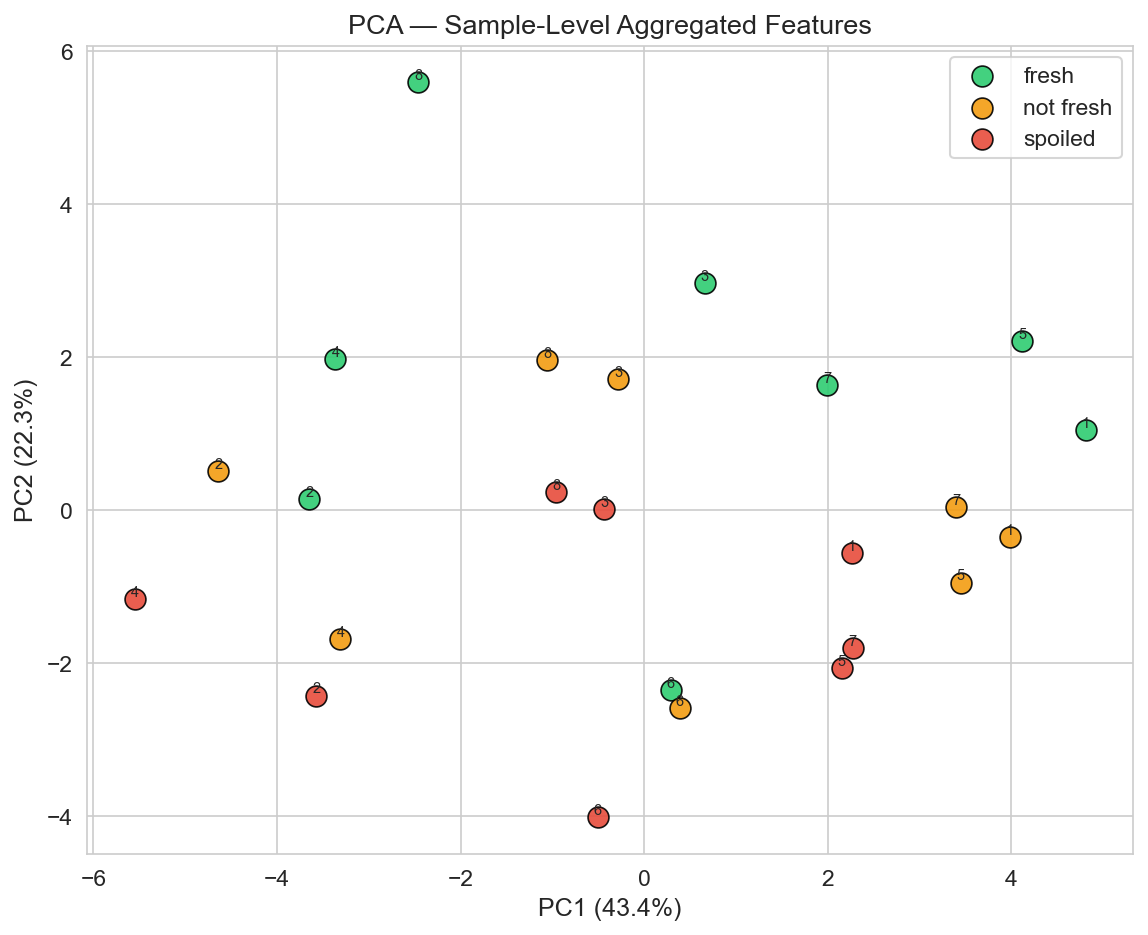

Saved -> E:\Thesis Code\results\visual_analysis\pca_aggregated.png


In [27]:
# ==============================================================
# 12.4  PCA visualization — aggregated data
# ==============================================================

scaler = StandardScaler()
X_agg_scaled = scaler.fit_transform(df_agg[FEATURE_COLS].values)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_agg_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for cls in CLASS_ORDER:
    mask = df_agg["label"].values == cls
    ax.scatter(
        pca_coords[mask, 0], pca_coords[mask, 1],
        label=cls, color=CLASS_PALETTE[cls], s=100,
        edgecolors="black", linewidth=0.8, alpha=0.9,
    )
    # Annotate with sample numbers
    for idx in np.where(mask)[0]:
        ax.annotate(
            str(df_agg.iloc[idx]["sample_number"]),
            (pca_coords[idx, 0], pca_coords[idx, 1]),
            fontsize=7, ha="center", va="bottom",
        )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — Sample-Level Aggregated Features")
ax.legend()
fig.savefig(RESULTS_DIR / "pca_aggregated.png")
plt.show()
plt.close(fig)
print(f"Saved -> {RESULTS_DIR / 'pca_aggregated.png'}")

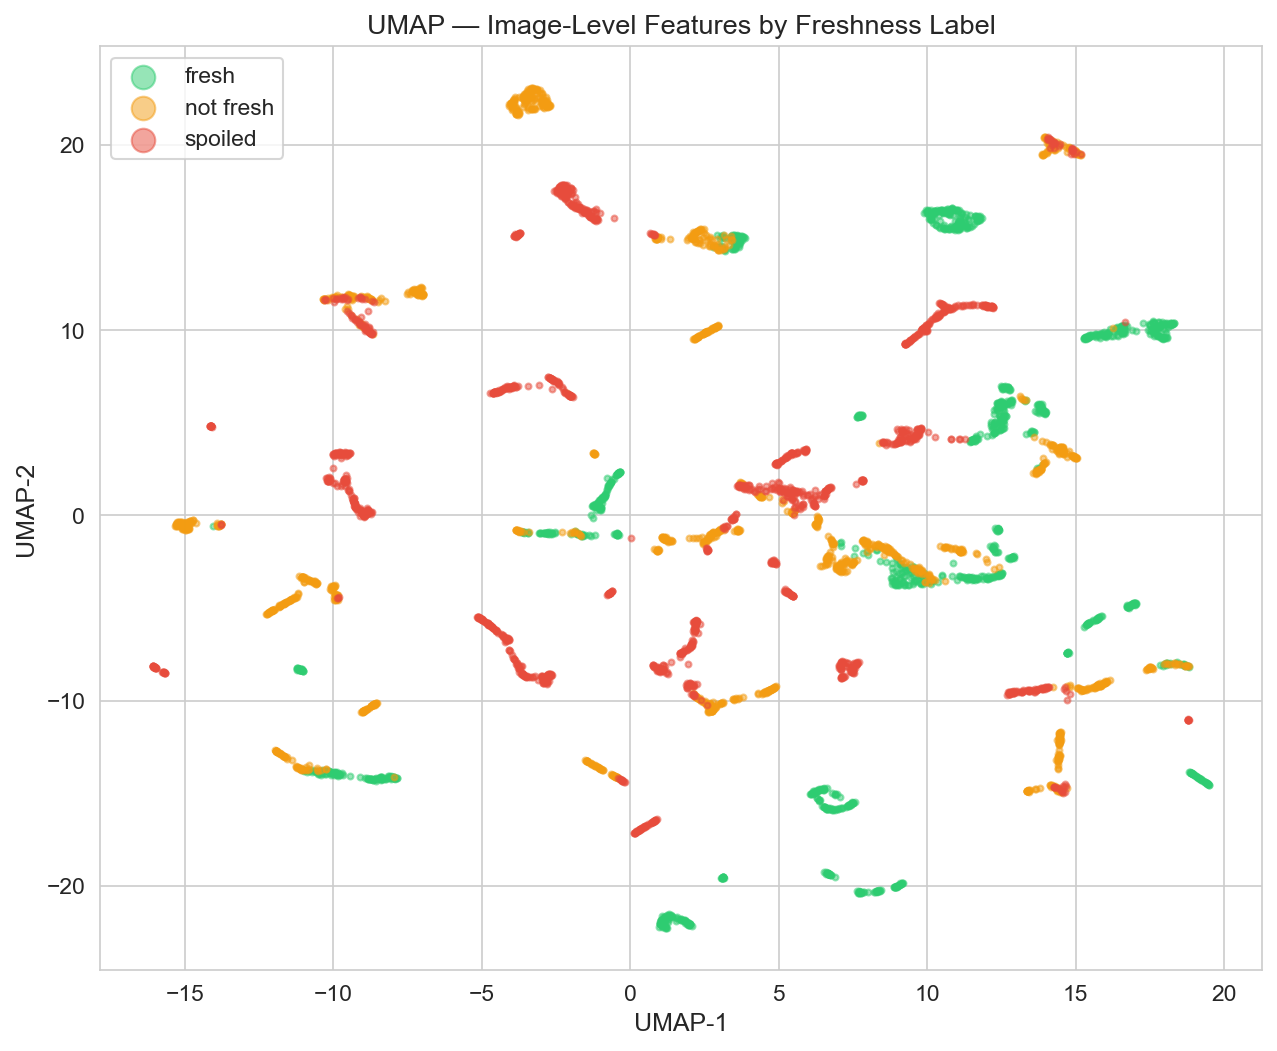

Saved -> E:\Thesis Code\results\visual_analysis\umap_image_level.png


In [28]:
# ==============================================================
# 12.5  UMAP visualization — image-level data
# ==============================================================

# Subsample for speed if dataset is very large
MAX_UMAP = 5000
if len(df_features) > MAX_UMAP:
    df_umap_data = df_features.sample(n=MAX_UMAP, random_state=42)
    print(f"Subsampled to {MAX_UMAP} images for UMAP.")
else:
    df_umap_data = df_features

X_umap_scaled = StandardScaler().fit_transform(df_umap_data[FEATURE_COLS].values)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
umap_coords = reducer.fit_transform(X_umap_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for cls in CLASS_ORDER:
    mask = df_umap_data["label"].values == cls
    ax.scatter(
        umap_coords[mask, 0], umap_coords[mask, 1],
        label=cls, color=CLASS_PALETTE[cls], s=8, alpha=0.5,
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("UMAP — Image-Level Features by Freshness Label")
ax.legend(markerscale=4)
fig.savefig(RESULTS_DIR / "umap_image_level.png")
plt.show()
plt.close(fig)
print(f"Saved -> {RESULTS_DIR / 'umap_image_level.png'}")

In [29]:
# ==============================================================
# 12.6  Correlation heatmaps
# ==============================================================

fig_dir_corr = RESULTS_DIR / "correlation_heatmaps"
fig_dir_corr.mkdir(parents=True, exist_ok=True)

# Overall correlation
corr_all = df_features[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_all, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.5, ax=ax, annot_kws={"size": 7},
)
ax.set_title("Feature Correlation — All Classes Combined")
fig.savefig(fig_dir_corr / "correlation_all.png")
plt.close(fig)

# Per-class correlations
for cls in CLASS_ORDER:
    subset = df_features[df_features["label"] == cls][FEATURE_COLS]
    corr_cls = subset.corr()
    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(
        corr_cls, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        square=True, linewidths=0.5, ax=ax, annot_kws={"size": 7},
    )
    ax.set_title(f"Feature Correlation — {cls.title()}")
    fig.savefig(fig_dir_corr / f"correlation_{cls.replace(' ', '_')}.png")
    plt.close(fig)

print(f"Saved correlation heatmaps -> {fig_dir_corr}")

Saved correlation heatmaps -> E:\Thesis Code\results\visual_analysis\correlation_heatmaps


In [30]:
# ==============================================================
# 12.7  Time trend plots -- per-sample regression lines
# ==============================================================

fig_dir_time = RESULTS_DIR / "time_trends"
fig_dir_time.mkdir(parents=True, exist_ok=True)

sample_colors = dict(zip(
    sorted(df_features["sample_number"].unique()),
    sns.color_palette("tab10", n_colors=len(sample_numbers)),
))

for feat in tqdm(FEATURE_COLS, desc="Time trend plots"):
    fig, ax = plt.subplots(figsize=(10, 5))

    for sn in sorted(df_time["sample_number"].unique()):
        sub = df_time[df_time["sample_number"] == sn]
        ax.scatter(
            sub["elapsed_minutes"], sub[feat],
            alpha=0.15, s=6, color=sample_colors[sn],
        )
        # Per-sample regression line
        valid = sub[["elapsed_minutes", feat]].dropna()
        if len(valid) > 2:
            z = np.polyfit(valid["elapsed_minutes"], valid[feat], 1)
            p_line = np.poly1d(z)
            x_range = np.linspace(
                valid["elapsed_minutes"].min(),
                valid["elapsed_minutes"].max(),
                100,
            )
            ax.plot(x_range, p_line(x_range), linewidth=1.5, alpha=0.8,
                    color=sample_colors[sn], label=f"S{sn}")

    ax.set_title(f"{feat} vs Elapsed Time (per-sample regression)")
    ax.set_xlabel("Elapsed Time (minutes)")
    ax.set_ylabel(feat)
    ax.legend(fontsize=7, ncol=4, loc="best")
    fig.savefig(fig_dir_time / f"time_{feat}.png")
    plt.close(fig)

print(f"Saved {len(FEATURE_COLS)} time-trend plots -> {fig_dir_time}")

Time trend plots:   0%|          | 0/20 [00:00<?, ?it/s]

Saved 20 time-trend plots -> E:\Thesis Code\results\visual_analysis\time_trends


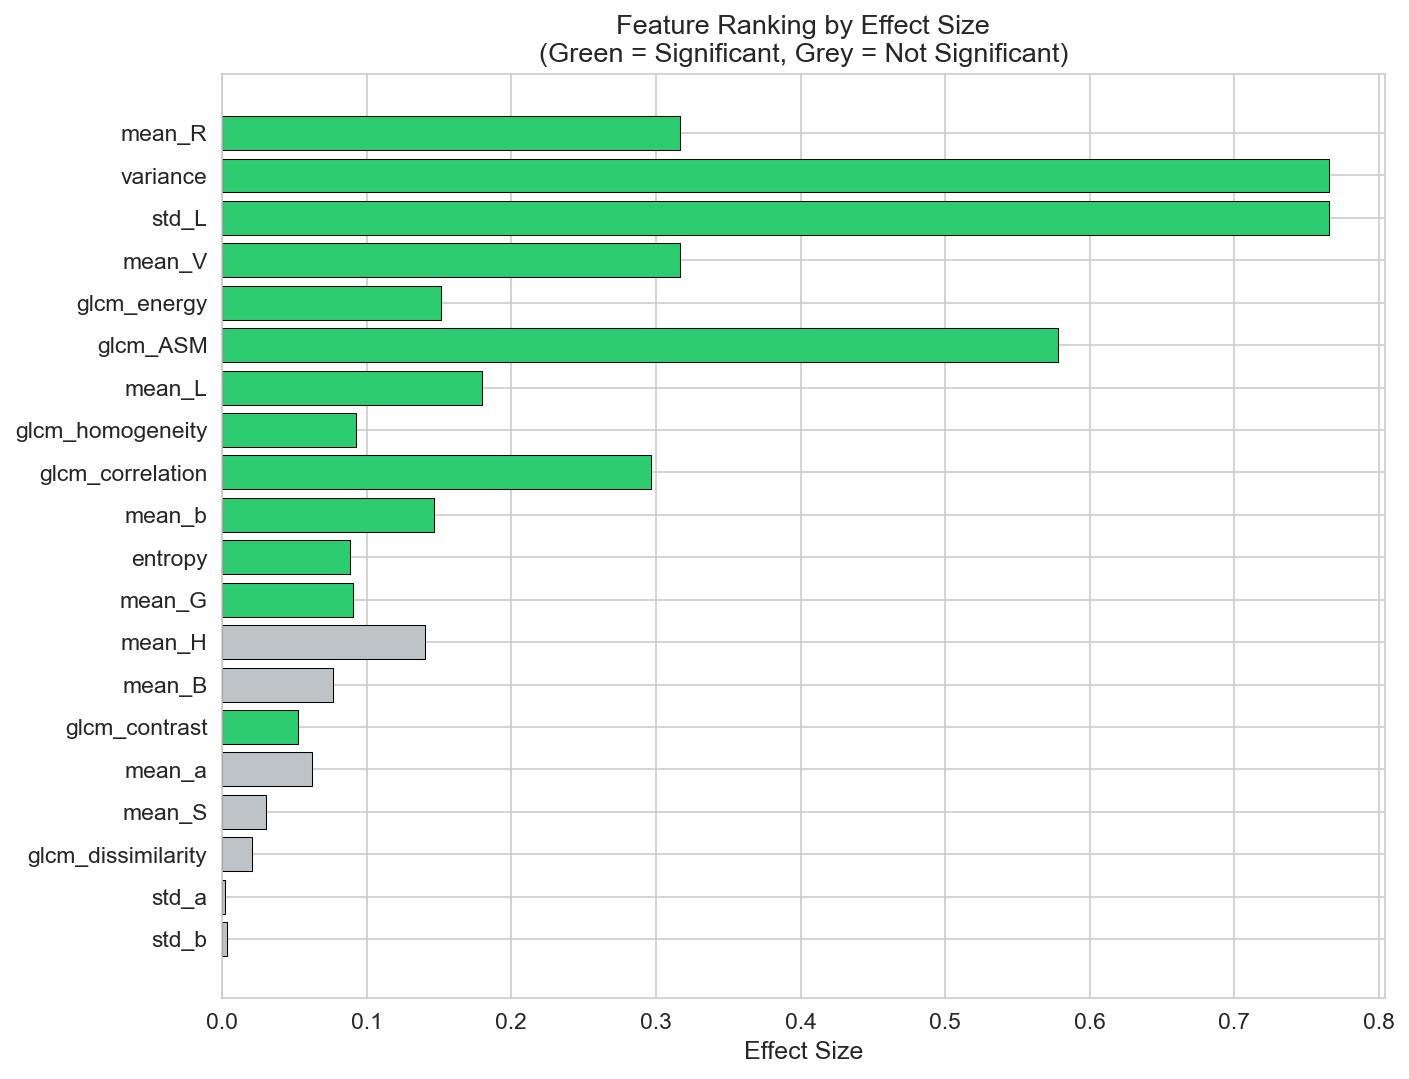

Saved -> E:\Thesis Code\results\visual_analysis\feature_ranking_barchart.png


In [31]:
# ==============================================================
# 12.8  Feature ranking bar chart
# ==============================================================

df_rank_sorted = df_rank.sort_values("overall_rank")

fig, ax = plt.subplots(figsize=(10, 8))
colors = []
for feat in df_rank_sorted["feature"]:
    sig = df_rm[df_rm["feature"] == feat]["significant"].values[0]
    colors.append("#2ecc71" if sig == "Yes" else "#bdc3c7")

ax.barh(
    range(len(df_rank_sorted)),
    df_rank_sorted["effect_size"].values,
    color=colors, edgecolor="black", linewidth=0.5,
)
ax.set_yticks(range(len(df_rank_sorted)))
ax.set_yticklabels(df_rank_sorted["feature"].values)
ax.set_xlabel("Effect Size")
ax.set_title("Feature Ranking by Effect Size\n(Green = Significant, Grey = Not Significant)")
ax.invert_yaxis()
fig.savefig(RESULTS_DIR / "feature_ranking_barchart.png")
plt.show()
plt.close(fig)
print(f"Saved -> {RESULTS_DIR / 'feature_ranking_barchart.png'}")

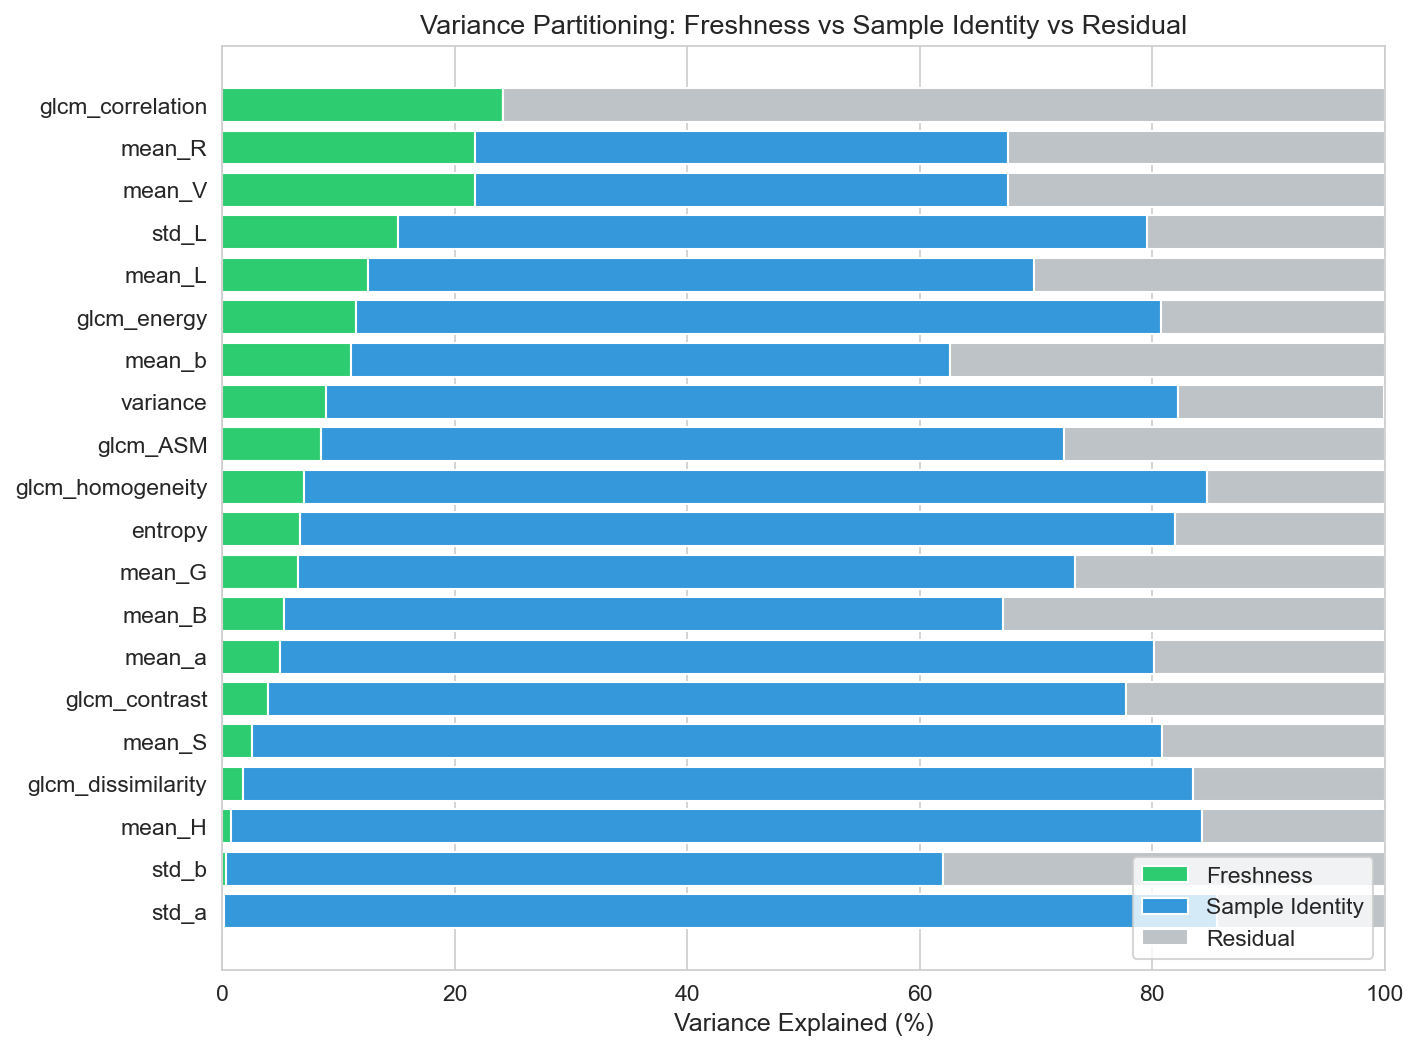

Saved -> E:\Thesis Code\results\visual_analysis\variance_partitioning.png


In [32]:
# ==============================================================
# 12.9  Variance partitioning stacked bar chart
# ==============================================================

df_var_plot = df_variance[df_variance["converged"]].copy()
df_var_plot = df_var_plot.sort_values("pct_freshness", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(df_var_plot))
ax.barh(y_pos, df_var_plot["pct_freshness"].values,
        color="#2ecc71", label="Freshness", edgecolor="white")
ax.barh(y_pos, df_var_plot["pct_sample"].values,
        left=df_var_plot["pct_freshness"].values,
        color="#3498db", label="Sample Identity", edgecolor="white")
ax.barh(y_pos, df_var_plot["pct_residual"].values,
        left=(df_var_plot["pct_freshness"] + df_var_plot["pct_sample"]).values,
        color="#bdc3c7", label="Residual", edgecolor="white")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_var_plot["feature"].values)
ax.set_xlabel("Variance Explained (%)")
ax.set_title("Variance Partitioning: Freshness vs Sample Identity vs Residual")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
fig.savefig(RESULTS_DIR / "variance_partitioning.png")
plt.show()
plt.close(fig)
print(f"Saved -> {RESULTS_DIR / 'variance_partitioning.png'}")

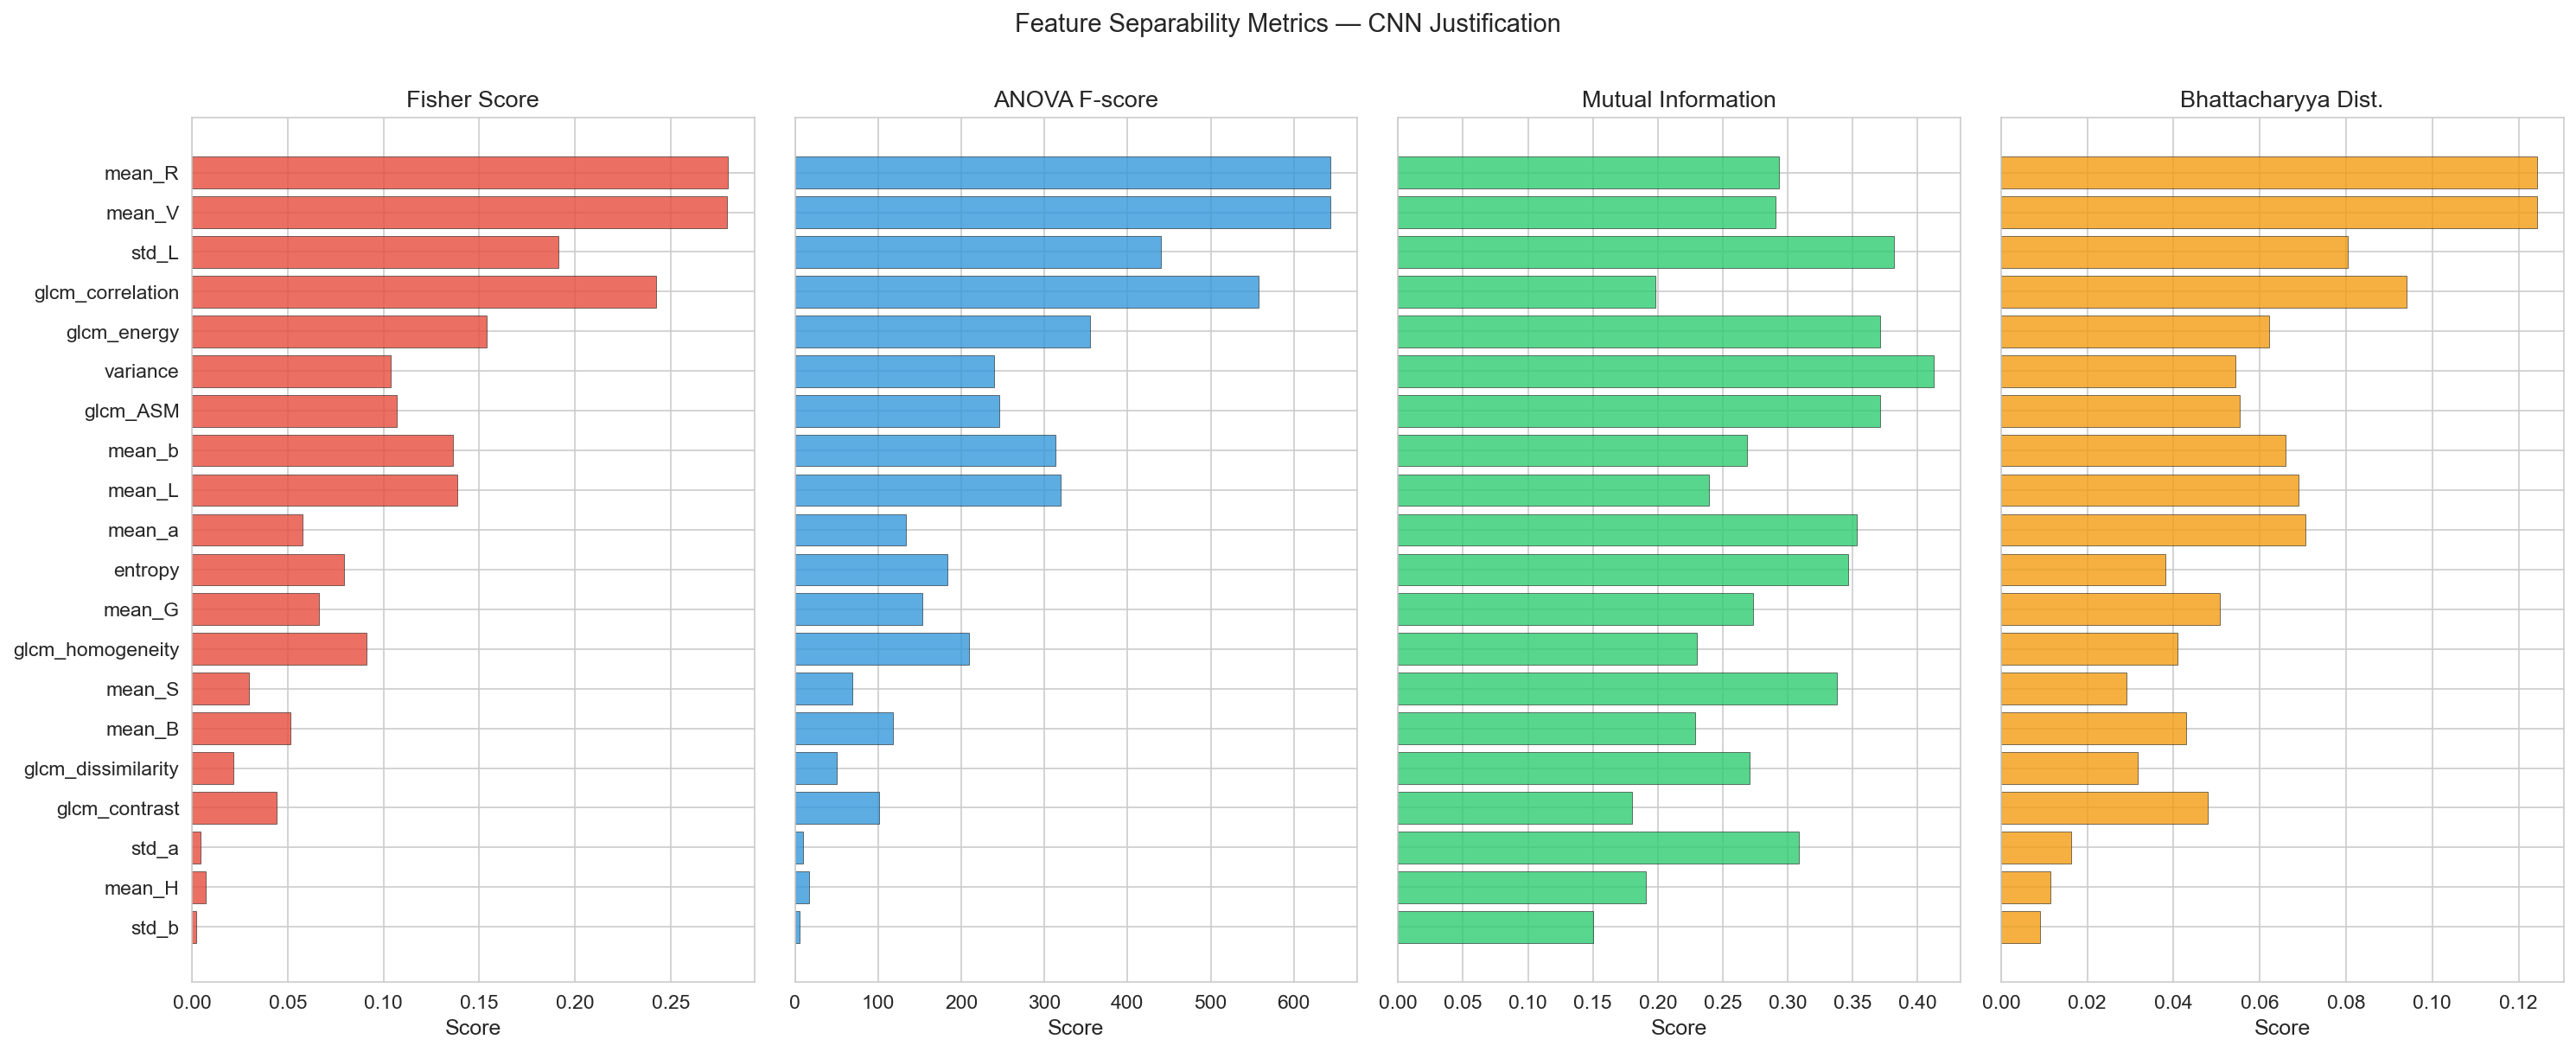

Saved -> E:\Thesis Code\results\visual_analysis\feature_separability.png


In [33]:
# ==============================================================
# 12.10  Feature separability bar chart
# ==============================================================

df_sep_sorted = df_separability.sort_values("composite_separability", ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True)
metrics = [
    ("fisher_score", "Fisher Score", "#e74c3c"),
    ("anova_f_score", "ANOVA F-score", "#3498db"),
    ("mutual_information", "Mutual Information", "#2ecc71"),
    ("bhattacharyya_dist", "Bhattacharyya Dist.", "#f39c12"),
]

for ax, (col, title, color) in zip(axes, metrics):
    ax.barh(range(len(df_sep_sorted)), df_sep_sorted[col].values,
            color=color, alpha=0.8, edgecolor="black", linewidth=0.3)
    ax.set_yticks(range(len(df_sep_sorted)))
    ax.set_yticklabels(df_sep_sorted["feature"].values)
    ax.set_title(title)
    ax.set_xlabel("Score")

fig.suptitle("Feature Separability Metrics — CNN Justification", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "feature_separability.png")
plt.show()
plt.close(fig)
print(f"Saved -> {RESULTS_DIR / 'feature_separability.png'}")

---
## Step 13 — Save All Results

Export all computed tables and ensure every figure has been saved.

In [34]:
# ==============================================================
# 13.1  Save CSVs
# ==============================================================

# visual_features.csv -- already saved in Step 2 (or loaded from cache)
features_path = BASE_DIR / "visual_features.csv"
if not features_path.exists():
    df_features.to_csv(features_path, index=False)
print(f"[OK] visual_features.csv              -> {features_path}")

# feature_statistics.csv -- saved in Step 3
print(f"[OK] feature_statistics.csv            -> {BASE_DIR / 'feature_statistics.csv'}")

# aggregated_sample_means.csv
agg_path = RESULTS_DIR / "aggregated_sample_means.csv"
df_agg.to_csv(agg_path, index=False)
print(f"[OK] aggregated_sample_means.csv       -> {agg_path}")

# repeated_measures_results.csv
rm_path = RESULTS_DIR / "repeated_measures_results.csv"
df_rm.to_csv(rm_path, index=False)
print(f"[OK] repeated_measures_results.csv     -> {rm_path}")

# posthoc_pairwise.csv
if not df_posthoc.empty:
    ph_path = RESULTS_DIR / "posthoc_pairwise.csv"
    df_posthoc.to_csv(ph_path, index=False)
    print(f"[OK] posthoc_pairwise.csv              -> {ph_path}")

# variance_partitioning.csv
var_path = RESULTS_DIR / "variance_partitioning.csv"
df_variance.to_csv(var_path, index=False)
print(f"[OK] variance_partitioning.csv         -> {var_path}")

# time_trend_per_sample.csv
time_path = RESULTS_DIR / "time_trend_per_sample.csv"
df_time_trends.to_csv(time_path, index=False)
print(f"[OK] time_trend_per_sample.csv         -> {time_path}")

# feature_ranking.csv -- saved in Step 10
print(f"[OK] feature_ranking.csv               -> {RESULTS_DIR / 'feature_ranking.csv'}")

# feature_separability.csv -- saved in Step 11
print(f"[OK] feature_separability.csv          -> {RESULTS_DIR / 'feature_separability.csv'}")

# ==============================================================
# 13.2  Summary of saved figures
# ==============================================================
print(f"\n[OK] All figures saved under           -> {RESULTS_DIR}")

# Count total figures
total_figs = sum(1 for _ in RESULTS_DIR.rglob("*.png"))
print(f"  Total figure files: {total_figs}")

print("\n" + "=" * 60)
print("Visual Feature Analysis Complete.")
print("=" * 60)

# ==============================================================
# 13.3  Final thesis-ready interpretation
# ==============================================================
print("\n" + "=" * 60)
print("THESIS-READY SUMMARY")
print("=" * 60)

print("\n1. FRESHNESS CLASS DIFFERENCES:")
n_sig = (df_rm["significant"] == "Yes").sum()
print(f"   {n_sig}/{len(FEATURE_COLS)} features show statistically significant "
      f"differences (repeated-measures design, alpha = {ALPHA}).")

print("\n2. FRESHNESS vs SAMPLE IDENTITY:")
df_v_ok = df_variance[df_variance["converged"]]
if not df_v_ok.empty:
    avg_fresh = df_v_ok["pct_freshness"].mean()
    avg_sample = df_v_ok["pct_sample"].mean()
    print(f"   Average variance explained by freshness: {avg_fresh:.1f}%")
    print(f"   Average variance explained by sample:    {avg_sample:.1f}%")
    if avg_fresh > avg_sample:
        print("   -> Freshness dominates over sample identity on average.")
    else:
        print("   -> Sample identity dominates — exercise caution in interpretation.")

print("\n3. MOST RELIABLE FRESHNESS INDICATORS (top 5):")
for i, row in df_rank.head(5).iterrows():
    print(f"   #{row['overall_rank']}: {row['feature']}  "
          f"(p={row['p_value']:.4f}, effect={row['effect_size']:.4f}, "
          f"consistency={row['consistency_pct']:.0f}%)")

print("\n4. CLASS SEPARABILITY:")
if not df_separability.empty:
    top_sep = df_separability.head(3)["feature"].tolist()
    avg_composite = df_separability["composite_separability"].mean()
    print(f"   Average composite separability: {avg_composite:.3f}")
    print(f"   Top separable features: {', '.join(top_sep)}")
    if avg_composite > 0.3:
        print("   -> Classes show meaningful visual separation in feature space.")
    else:
        print("   -> Limited visual separation — CNN may need to learn more complex features.")

print("\n" + "=" * 60)

[OK] visual_features.csv              -> E:\Thesis Code\visual_features.csv
[OK] feature_statistics.csv            -> E:\Thesis Code\feature_statistics.csv
[OK] aggregated_sample_means.csv       -> E:\Thesis Code\results\visual_analysis\aggregated_sample_means.csv
[OK] repeated_measures_results.csv     -> E:\Thesis Code\results\visual_analysis\repeated_measures_results.csv
[OK] posthoc_pairwise.csv              -> E:\Thesis Code\results\visual_analysis\posthoc_pairwise.csv
[OK] variance_partitioning.csv         -> E:\Thesis Code\results\visual_analysis\variance_partitioning.csv
[OK] time_trend_per_sample.csv         -> E:\Thesis Code\results\visual_analysis\time_trend_per_sample.csv
[OK] feature_ranking.csv               -> E:\Thesis Code\results\visual_analysis\feature_ranking.csv
[OK] feature_separability.csv          -> E:\Thesis Code\results\visual_analysis\feature_separability.csv

[OK] All figures saved under           -> E:\Thesis Code\results\visual_analysis
  Total figure file